# 05. Геометрическое броуновское движение

**Статус:** завершено

В этом ноутбуке мы изучаем геометрическое броуновское движение (GBM) как базовую модель положительной цены актива: точное решение SDE, логнормальное распределение, роль сноса и волатильности, среднее и медиану, барьерные события и риск-нейтральную интуицию.

## Теория и интуиция

Геометрическое броуновское движение задаётся стохастическим дифференциальным уравнением

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t,
$$

где $S_t>0$ — цена, $\mu$ — снос, $\sigma$ — волатильность. По формуле Ито точное решение имеет вид

$$
S_t = S_0\exp\left((\mu-\tfrac12\sigma^2)t + \sigma W_t\right).
$$

Отсюда следует, что логарифм цены нормален:

$$
\log S_t \sim N\left(\log S_0 + (\mu-\tfrac12\sigma^2)t,\ \sigma^2 t\right),
$$

а сама цена логнормальна. Математическое ожидание и дисперсия:

$$
\mathbb{E}[S_t]=S_0e^{\mu t},
$$

$$
\mathrm{Var}(S_t)=S_0^2e^{2\mu t}(e^{\sigma^2t}-1).
$$

Медиана равна

$$
\mathrm{median}(S_t)=S_0e^{(\mu-\frac12\sigma^2)t}.
$$

Среднее обычно выше медианы, потому что логнормальное распределение имеет длинный правый хвост.

## Импорты и функции

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.geometric_brownian_motion import (
    calculate_discounted_price_paths,
    calculate_empirical_mean_variance_and_median_across_paths,
    calculate_log_returns_from_price_paths,
    calculate_theoretical_gbm_mean_variance_and_median,
    calculate_theoretical_probability_of_terminal_price_exceeding_level,
    estimate_probability_of_reaching_price_barrier_before_maturity,
    plot_gbm_log_return_distribution_with_normal_density,
    plot_gbm_mean_median_and_simulation,
    plot_gbm_parameter_scenarios,
    plot_geometric_brownian_motion_sample_paths,
    plot_terminal_gbm_distribution_with_lognormal_density,
    simulate_multiple_geometric_brownian_motion_paths,
)

## 1. Траектории GBM

GBM сохраняет цену положительной: экспонента никогда не становится отрицательной. Но траектории могут сильно расходиться из-за мультипликативного шума: один и тот же относительный шок действует тем сильнее в абсолютных единицах, чем выше текущая цена.

,S(1)
Траектория 1,139.6923
Траектория 2,81.8479
Траектория 3,116.5106
Траектория 4,128.9882
Траектория 5,108.5298
Траектория 6,106.4690
Траектория 7,109.6335
Траектория 8,93.4221


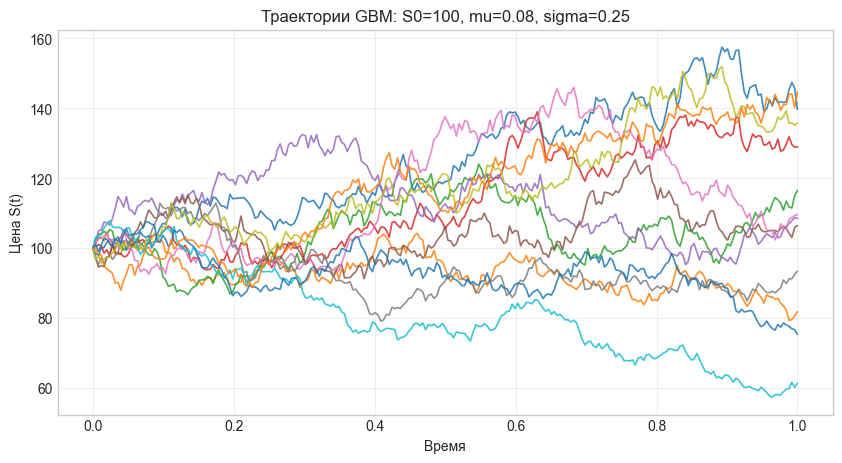

In [2]:
gbm_time_grid, gbm_price_paths = simulate_multiple_geometric_brownian_motion_paths(
    number_of_paths=10000,
    number_of_time_steps=252,
    final_time=1.0,
    initial_price=100.0,
    drift=0.08,
    volatility=0.25,
    random_seed=123,
)

plot_geometric_brownian_motion_sample_paths(
    time_grid=gbm_time_grid,
    simulated_price_paths=gbm_price_paths[:12],
    number_of_paths_to_plot=12,
    title="Траектории GBM: S0=100, mu=0.08, sigma=0.25",
);

pd.DataFrame(
    {"S(1)": gbm_price_paths[:8, -1]},
    index=[f"Траектория {index}" for index in range(1, 9)],
)

На графике видно, что цены остаются положительными, но веер траекторий расширяется со временем. Это не аддитивная модель шума: случайность действует на относительные изменения, поэтому разброс в абсолютных ценах растёт вместе с уровнем цены.

Именно поэтому GBM исторически стал удобной моделью для акций: отрицательные цены невозможны, а лог-доходности имеют простую нормальную структуру. Но эта же простота ограничивает модель: постоянная волатильность и нормальные лог-доходности часто плохо описывают реальные хвосты финансовых данных.

## 2. Среднее, медиана и дисперсия

Сравним эмпирические характеристики с точными формулами. В GBM среднее и медиана расходятся, потому что распределение цены асимметрично.

,Время,Эмпирическое среднее,Теоретическое среднее,Эмпирическая медиана,Теоретическая медиана,Эмпирическая дисперсия,Теоретическая дисперсия
0,0.5,104.3099,104.0811,102.6146,102.4674,332.2653,343.8722
1,1.0,108.8083,108.3287,105.6184,104.9958,742.7395,756.8495


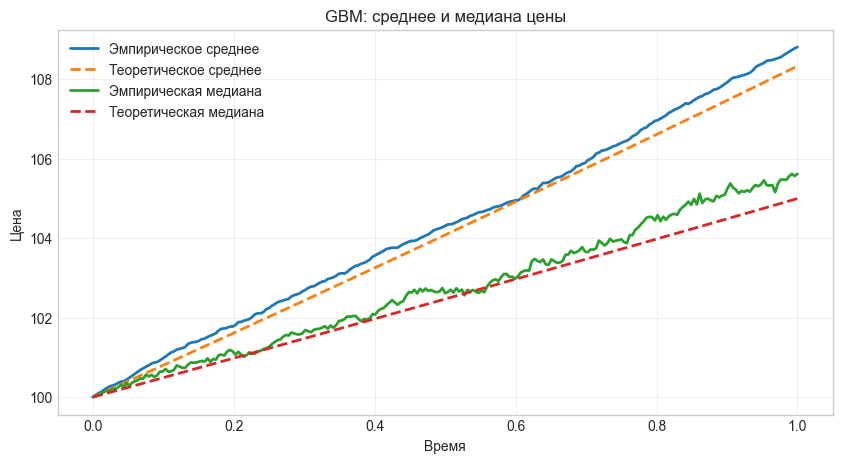

In [3]:
gbm_empirical_mean, gbm_empirical_variance, gbm_empirical_median = calculate_empirical_mean_variance_and_median_across_paths(
    gbm_price_paths
)
gbm_theoretical_mean, gbm_theoretical_variance, gbm_theoretical_median = calculate_theoretical_gbm_mean_variance_and_median(
    time_grid=gbm_time_grid,
    initial_price=100.0,
    drift=0.08,
    volatility=0.25,
)

plot_gbm_mean_median_and_simulation(
    time_grid=gbm_time_grid,
    empirical_mean=gbm_empirical_mean,
    empirical_median=gbm_empirical_median,
    theoretical_mean=gbm_theoretical_mean,
    theoretical_median=gbm_theoretical_median,
    title="GBM: среднее и медиана цены",
);

selected_gbm_indices = [126, 252]
pd.DataFrame(
    {
        "Время": gbm_time_grid[selected_gbm_indices],
        "Эмпирическое среднее": gbm_empirical_mean[selected_gbm_indices],
        "Теоретическое среднее": gbm_theoretical_mean[selected_gbm_indices],
        "Эмпирическая медиана": gbm_empirical_median[selected_gbm_indices],
        "Теоретическая медиана": gbm_theoretical_median[selected_gbm_indices],
        "Эмпирическая дисперсия": gbm_empirical_variance[selected_gbm_indices],
        "Теоретическая дисперсия": gbm_theoretical_variance[selected_gbm_indices],
    }
)

В момент `t=0.5` эмпирическое среднее равно `104.3099` против теоретического `104.0811`, а медиана `102.6146` против `102.4674`. В момент `t=1.0` среднее `108.8083` близко к теоретическому `108.3287`, а медиана `105.6184` близка к `104.9958`.

Среднее выше медианы, и это принципиально. Большинство траекторий может быть около медианного сценария, но редкие сильные росты тянут среднее вверх. Поэтому для логнормальных моделей полезно смотреть не только ожидание, но и квантили.

## 3. Логнормальное распределение конечной цены

Так как $\log S_T$ нормально распределён, $S_T$ имеет логнормальное распределение. Проверим форму распределения и несколько вероятностей.

,Показатель,Значение
0,Среднее S(1),108.8083
1,Дисперсия S(1),742.7395
2,5%-квантиль,69.9827
3,Медиана,105.6184
4,95%-квантиль,158.7822
5,P(S(1) >= 120) по симуляции,0.3018
6,P(S(1) >= 120) по теории,0.2966


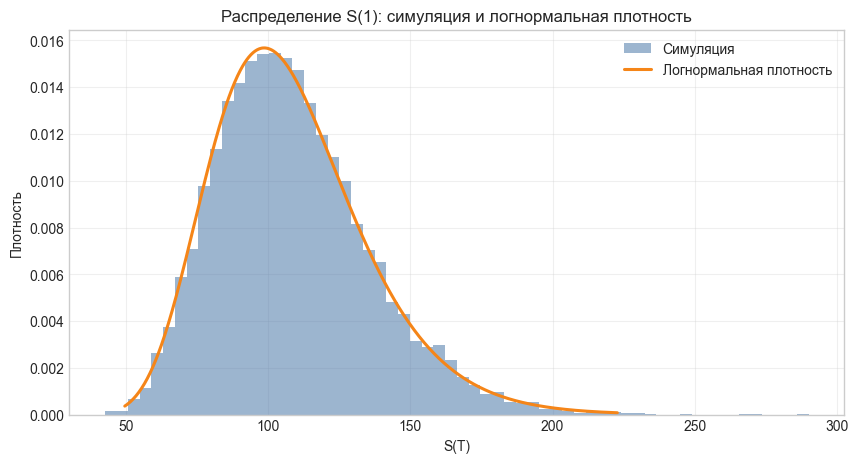

In [4]:
gbm_terminal_prices = gbm_price_paths[:, -1]

plot_terminal_gbm_distribution_with_lognormal_density(
    terminal_prices=gbm_terminal_prices,
    initial_price=100.0,
    drift=0.08,
    volatility=0.25,
    final_time=1.0,
    title="Распределение S(1): симуляция и логнормальная плотность",
);

pd.DataFrame(
    {
        "Показатель": [
            "Среднее S(1)",
            "Дисперсия S(1)",
            "5%-квантиль",
            "Медиана",
            "95%-квантиль",
            "P(S(1) >= 120) по симуляции",
            "P(S(1) >= 120) по теории",
        ],
        "Значение": [
            gbm_terminal_prices.mean(),
            gbm_terminal_prices.var(),
            np.quantile(gbm_terminal_prices, 0.05),
            np.quantile(gbm_terminal_prices, 0.50),
            np.quantile(gbm_terminal_prices, 0.95),
            np.mean(gbm_terminal_prices >= 120.0),
            calculate_theoretical_probability_of_terminal_price_exceeding_level(
                initial_price=100.0,
                drift=0.08,
                volatility=0.25,
                final_time=1.0,
                price_level=120.0,
            ),
        ],
    }
)

Гистограмма имеет характерную правую асимметрию. В симуляции 5%-квантиль равен `69.9827`, медиана `105.6184`, а 95%-квантиль `158.7822`. Верхний хвост далеко уходит вправо.

Вероятность закончить год выше `120` по симуляции равна `0.3018`, а точная логнормальная формула даёт `0.2966`. Разница мала и объясняется конечным числом траекторий.

## 4. Лог-доходности

Из точного решения следует, что однопериодная лог-доходность

$$
\log\frac{S_{t+\Delta t}}{S_t}
$$

имеет нормальное распределение со средним $(\mu-\frac12\sigma^2)\Delta t$ и дисперсией $\sigma^2\Delta t$.

,Показатель,Значение
0,Среднее лог-доходности,0.0002
1,Теоретическое среднее,0.0002
2,Дисперсия лог-доходности,0.0002
3,Теоретическая дисперсия,0.0002


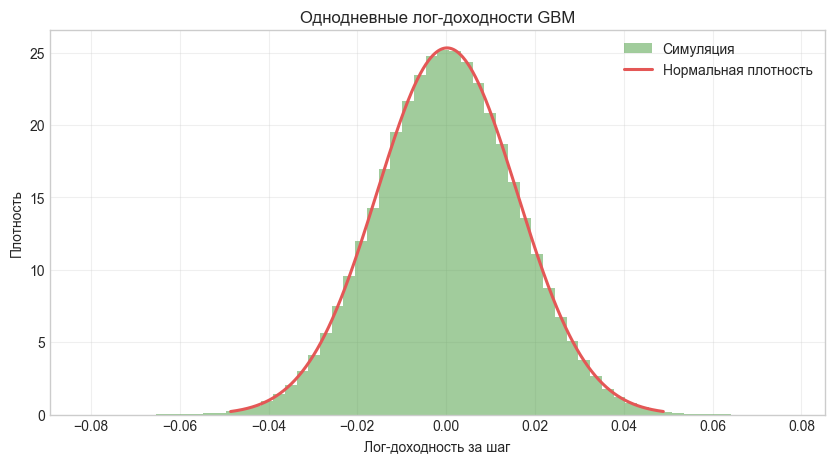

In [5]:
gbm_log_returns = calculate_log_returns_from_price_paths(gbm_price_paths)
gbm_time_step = gbm_time_grid[1] - gbm_time_grid[0]

plot_gbm_log_return_distribution_with_normal_density(
    log_returns=gbm_log_returns,
    drift=0.08,
    volatility=0.25,
    time_step=gbm_time_step,
    title="Однодневные лог-доходности GBM",
);

pd.DataFrame(
    {
        "Показатель": ["Среднее лог-доходности", "Теоретическое среднее", "Дисперсия лог-доходности", "Теоретическая дисперсия"],
        "Значение": [
            gbm_log_returns.mean(),
            (0.08 - 0.5 * 0.25**2) * gbm_time_step,
            gbm_log_returns.var(),
            0.25**2 * gbm_time_step,
        ],
    }
)

Среднее однодневной лог-доходности получилось `0.000214`, а теория даёт `0.00019345`. Дисперсия равна `0.00024763` против теоретических `0.00024802`. Совпадение очень хорошее.

Здесь важно не перепутать доходности: простая доходность $S_{t+\Delta t}/S_t-1$ не является нормально распределённой, а лог-доходность в GBM нормальна. Поэтому многие формулы в модели Блэка — Шоулза записываются именно через логарифмы цен.

## 5. Как снос и волатильность меняют процесс

Снос $\mu$ управляет средним ростом $E[S_t]$, а волатильность $\sigma$ влияет на разброс и одновременно снижает медианный рост через член $-\frac12\sigma^2$ в логарифме цены.

,Сценарий,E[S(1)],median[S(1)],std[S(1)]
0,"низкий рост, низкая волатильность",103.0455,102.5315,10.3304
1,"высокий рост, низкая волатильность",110.5171,109.9659,11.0794
2,"высокий рост, высокая волатильность",110.5171,103.9511,39.8964


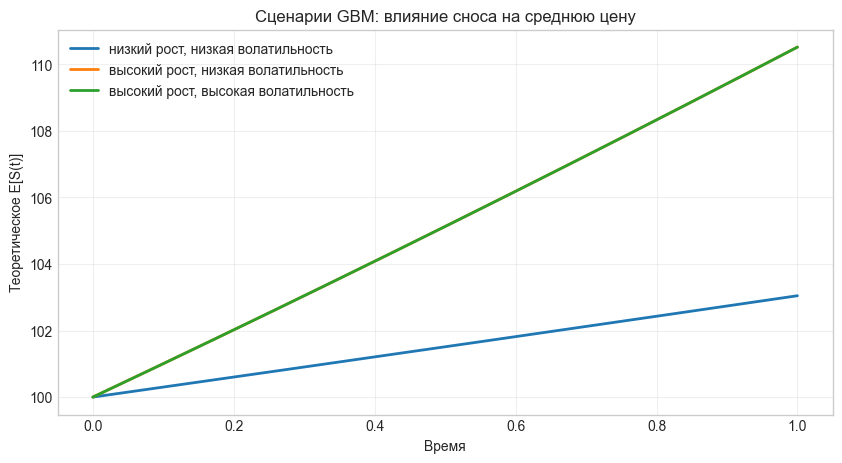

In [6]:
scenario_results = {}
scenario_rows = []
for scenario_name, drift, volatility in [
    ("низкий рост, низкая волатильность", 0.03, 0.10),
    ("высокий рост, низкая волатильность", 0.10, 0.10),
    ("высокий рост, высокая волатильность", 0.10, 0.35),
]:
    scenario_time_grid = np.linspace(0.0, 1.0, 253)
    scenario_mean, scenario_variance, scenario_median = calculate_theoretical_gbm_mean_variance_and_median(
        time_grid=scenario_time_grid,
        initial_price=100.0,
        drift=drift,
        volatility=volatility,
    )
    scenario_results[scenario_name] = (scenario_time_grid, scenario_mean)
    scenario_rows.append(
        {
            "Сценарий": scenario_name,
            "E[S(1)]": scenario_mean[-1],
            "median[S(1)]": scenario_median[-1],
            "std[S(1)]": np.sqrt(scenario_variance[-1]),
        }
    )

plot_gbm_parameter_scenarios(
    scenario_results=scenario_results,
    title="Сценарии GBM: влияние сноса на среднюю цену",
);

pd.DataFrame(scenario_rows)

Высокий снос поднимает среднее: при $\mu=0.10$ теоретическое $E[S(1)]$ выше, чем при $\mu=0.03$. Но высокая волатильность резко увеличивает стандартное отклонение конечной цены и одновременно делает медиану ниже среднего.

Это важная интуиция: волатильность не просто «добавляет шум». В логарифме цены она входит как $-\frac12\sigma^2$, поэтому типичная траектория может расти медленнее среднего, если редкие большие положительные исходы сильно тянут ожидание вверх.

## 6. Барьер и риск-нейтральная интуиция

Барьерное событие зависит от максимума траектории, а не только от конечной цены. Поэтому вероятность когда-либо достичь уровня обычно выше, чем вероятность закончить выше этого уровня.

В риск-нейтральной модели с $\mu=r$ дисконтированная цена $e^{-rt}S_t$ должна быть мартингалом: её среднее остаётся около $S_0$.

In [7]:
barrier_probability = estimate_probability_of_reaching_price_barrier_before_maturity(
    simulated_price_paths=gbm_price_paths,
    price_barrier=130.0,
)

risk_neutral_time_grid, risk_neutral_price_paths = simulate_multiple_geometric_brownian_motion_paths(
    number_of_paths=8000,
    number_of_time_steps=252,
    final_time=1.0,
    initial_price=100.0,
    drift=0.05,
    volatility=0.25,
    random_seed=456,
)
risk_neutral_discounted_paths = calculate_discounted_price_paths(
    simulated_price_paths=risk_neutral_price_paths,
    time_grid=risk_neutral_time_grid,
    risk_free_rate=0.05,
)

pd.DataFrame(
    {
        "Показатель": [
            "P(max S(t) >= 130) по симуляции",
            "Среднее дисконтированной цены в t=0",
            "Среднее дисконтированной цены в t=1",
            "Стандартное отклонение дисконтированной цены в t=1",
        ],
        "Значение": [
            barrier_probability,
            risk_neutral_discounted_paths[:, 0].mean(),
            risk_neutral_discounted_paths[:, -1].mean(),
            risk_neutral_discounted_paths[:, -1].std(),
        ],
    }
)

,Показатель,Значение
0,P(max S(t) >= 130) по симуляции,0.3394
1,Среднее дисконтированной цены в t=0,100.0000
2,Среднее дисконтированной цены в t=1,99.7570
3,Стандартное отклонение дисконтированной цены в...,25.0091


Вероятность хотя бы раз достичь уровня `130` на годовом горизонте получилась `0.3394`. Это выше вероятности закончить выше `120`, и тем более не сводится к одному конечному распределению: траектория может подняться выше барьера, а затем закончить ниже.

В риск-нейтральном эксперименте среднее дисконтированной цены в начале равно `100.0`, а в конце `99.7570`. Отклонение от 100 связано с конечным числом симуляций. Это иллюстрирует мартингальную идею ценообразования: под риск-нейтральной мерой ожидаемая дисконтированная цена не должна систематически расти.

## Основные выводы

1. GBM сохраняет цену положительной и задаёт нормальное распределение лог-цены.
2. Среднее, медиана и квантили расходятся из-за правой асимметрии логнормального распределения.
3. Снос $\mu$ управляет средним ростом, а волатильность $\sigma$ управляет разбросом и снижает медианный лог-тренд через $-\frac12\sigma^2$.
4. Лог-доходности в GBM нормальны с дисперсией $\sigma^2\Delta t$.
5. Барьерные события зависят от всей траектории, а не только от $S_T$.
6. В риск-нейтральной постановке дисконтированная цена ведёт себя как мартингал, что лежит в основе классического финансового ценообразования.
7. Ограничения GBM важны: постоянная волатильность, независимые нормальные лог-доходности и отсутствие скачков часто слишком упрощают реальные рынки.